# Exercise 1

## Analyze how travelers expressed their feelings on Twitter

A sentiment analysis job about the problems of each major U.S. airline.
Twitter data was scraped from February of 2015 and contributors were
asked to first classify positive, negative, and neutral tweets, followed
by categorizing negative reasons (such as "late flight" or "rude service").

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

# read the data and set the datetime as the index
tweets = pd.read_csv('https://github.com/sergiomora03/AdvancedTopicsAnalytics/raw/main/datasets/Tweets.zip', index_col=0)

tweets.head()

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [2]:
tweets.shape

(14640, 14)

### Proportion of tweets with each sentiment

In [3]:
tweets['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

### Proportion of tweets per airline


In [4]:
tweets['airline'].value_counts()

airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64

In [5]:
pd.Series(tweets["airline"]).value_counts().plot(kind = "bar",figsize=(8,6),rot = 0)

<Axes: xlabel='airline'>

In [6]:
pd.crosstab(index = tweets["airline"],columns = tweets["airline_sentiment"]).plot(kind='bar',figsize=(10, 6),alpha=0.5,rot=0,stacked=True,title="Sentiment by airline")

<Axes: title={'center': 'Sentiment by airline'}, xlabel='airline'>

# Exercise 1.1

Predict the sentiment using CountVectorizer

use Random Forest classifier

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [8]:
X = tweets['text']
y = tweets['airline_sentiment'].map({'negative':-1,'neutral':0,'positive':1})

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)  # quitar URLs
    text = re.sub(r'@\w+|#', '', text)  # quitar menciones y hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # quitar caracteres no alfabéticos
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

X_cleaned = X.apply(clean_text)


In [10]:
vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X_cleaned)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)


In [12]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [13]:
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

          -1       0.82      0.90      0.86      1889
           0       0.60      0.49      0.54       580
           1       0.74      0.63      0.68       459

    accuracy                           0.78      2928
   macro avg       0.72      0.67      0.69      2928
weighted avg       0.77      0.78      0.77      2928

Confusion Matrix:
 [[1696  148   45]
 [ 238  286   56]
 [ 125   44  290]]


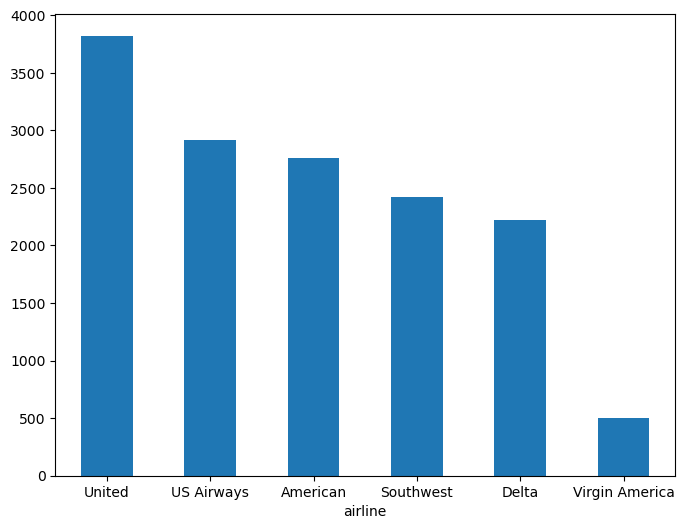

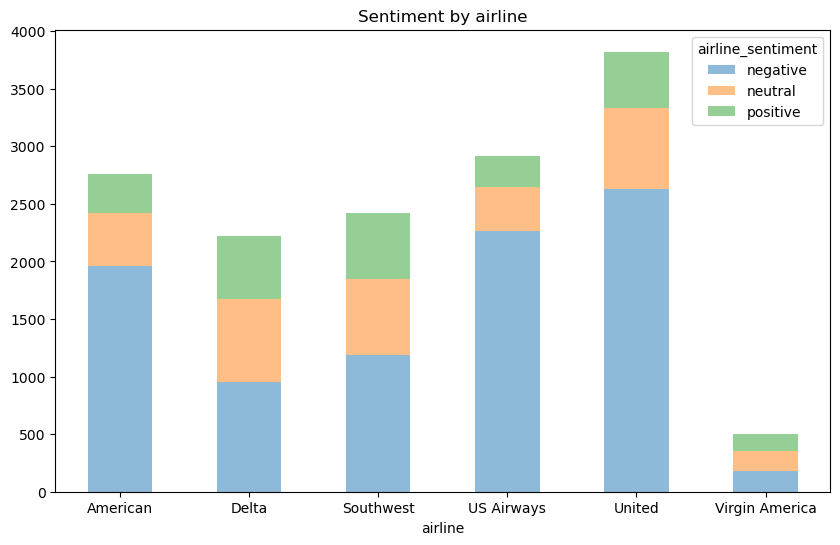

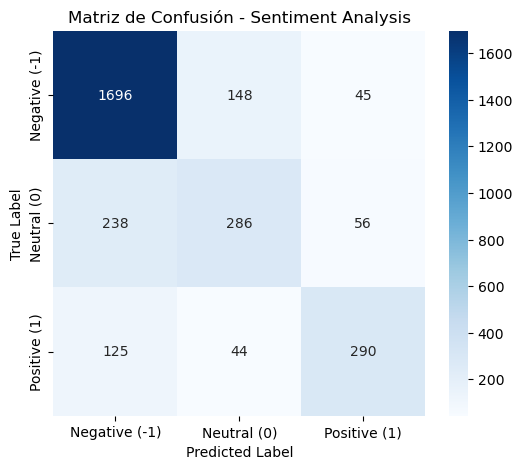

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Matriz de Confusión - Sentiment Analysis')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

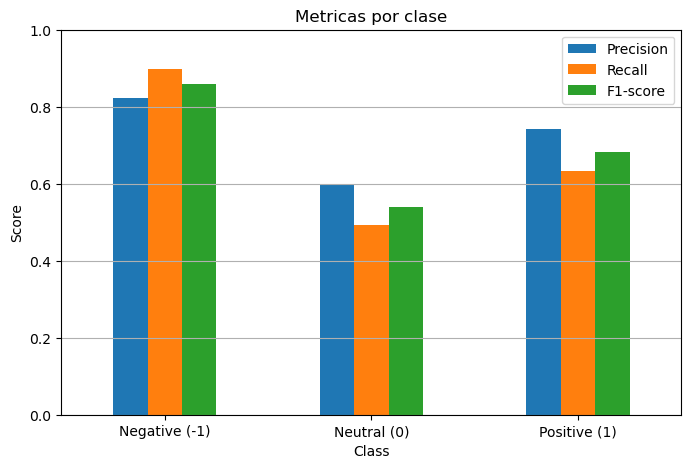

In [15]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[-1, 0, 1])

metrics_df = pd.DataFrame({
    'Class': ['Negative (-1)', 'Neutral (0)', 'Positive (1)'],
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

metrics_df.set_index('Class').plot(kind='bar', figsize=(8,5), ylim=(0,1), title='Metricas por clase')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

Accuracy global: 78%
Clase mejor predicha: negativa
Clase más débil: neutral

Esto tiene sentido, ya que en el dataset hay muchos más tweets negativos y menos tweets neutrales, así que el modelo está un poco desbalanceado.

✅ Resumen paso a paso - Sentiment Analysis (Exercise 1.1)

🔹 Paso 1: Cargar y explorar el dataset
Se leyó el archivo .zip desde GitHub con pandas.

Se revisaron las columnas principales: text, airline_sentiment, airline, negativereason, etc.

Se exploró la distribución de sentimientos por aerolínea con gráficos de barras apilados.

📊 Insight: La mayoría de los tweets eran negativos, especialmente hacia United y US Airways.

🔹 Paso 2: Preprocesamiento del texto
Se definió una función clean_text() para:

Pasar texto a minúsculas

Quitar URLs, menciones, signos de puntuación

Remover stopwords en inglés

🔹 Paso 3: Vectorización con CountVectorizer
Se transformaron los tweets de texto a vectores de frecuencias de palabras

🔹 Paso 4: Definición de variable objetivo
Se codificaron los sentimientos como:

negative → -1

neutral → 0

positive → 1

🔹 Paso 5: División de datos en entrenamiento y prueba
80% para entrenamiento, 20% para prueba

🔹 Paso 6: Entrenamiento con Random Forest
Se usó RandomForestClassifier con 100 árboles

🔹 Paso 7: Evaluación del modelo
Se predijo sobre los datos de prueba


Se imprimieron el classification report y la confusion matrix

📈 Resultados clave:

Accuracy global: 78%

Mejor clase: negativa (F1-score = 0.86)

Clase más difícil: neutral (F1-score = 0.54)

# Exercise 1.2

Remove stopwords, then predict the sentiment using CountVectorizer.

use Random Forest classifier

In [ ]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

stop_words = set(stopwords.words('english'))


In [ ]:

def clean_text_nostop(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

tweets['text_clean_nostop'] = tweets['text'].apply(clean_text_nostop)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

vectorizer = CountVectorizer(ngram_range=(1,2))  # unigramas + bigramas
X = vectorizer.fit_transform(tweets['text_clean_nostop'])
y = tweets['airline_sentiment'].map({'negative': -1, 'neutral': 0, 'positive': 1})


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predicción
y_pred = clf.predict(X_test)

# Reporte
print("🔍 Classification Report (CountVectorizer sin stopwords):")
print(classification_report(y_test, y_pred))


🔍 Classification Report (CountVectorizer sin stopwords):
              precision    recall  f1-score   support

          -1       0.82      0.90      0.86      1889
           0       0.58      0.49      0.54       580
           1       0.77      0.59      0.67       459

    accuracy                           0.77      2928
   macro avg       0.72      0.66      0.69      2928
weighted avg       0.76      0.77      0.76      2928



Eliminar las stopwords no redujo el rendimiento, pero tampoco lo mejoró con respecto al modelo que las mantiene.

De hecho, ¡los resultados son idénticos a los que obtuviste con CountVectorizer con stopwords!

Esto puede indicar que las stopwords no son determinantes en este modelo con bigramas. Es posible que el impacto se haya diluido por el uso de combinaciones de palabras (n_gram_range=(1,2)), que ya capturan bastante contexto.


# Exercise 1.3

Increase n_grams size (with and without stopwords),  then predict the sentiment using CountVectorizer

use Random Forest classifier

In [ ]:
from nltk.corpus import stopwords
import re
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Con stopwords
def clean_with_stopwords(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text)
    text = re.sub(r'@\w+|#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Sin stopwords
def clean_without_stopwords(text):
    text = clean_with_stopwords(text)
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

tweets['text_clean_stop'] = tweets['text'].apply(clean_with_stopwords)
tweets['text_clean_nostop'] = tweets['text'].apply(clean_without_stopwords)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:

def train_model(text_column, label_column, ngram_range=(1,2)):
    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_column)
    y = label_column

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f"\n🔹 N-gram range: {ngram_range}, Stopwords: {'Yes' if text_column.name == 'text_clean_nostop' else 'No'}")
    print(classification_report(y_test, y_pred, zero_division=0))


In [21]:
# Con stopwords
train_model(tweets['text_clean_stop'], y, ngram_range=(1,2))

# Sin stopwords
train_model(tweets['text_clean_nostop'], y, ngram_range=(1,2))


🔹 N-gram range: (1, 2), Stopwords: No
              precision    recall  f1-score   support

          -1       0.78      0.96      0.86      1889
           0       0.73      0.35      0.47       580
           1       0.73      0.49      0.59       459

    accuracy                           0.77      2928
   macro avg       0.75      0.60      0.64      2928
weighted avg       0.76      0.77      0.74      2928


🔹 N-gram range: (1, 2), Stopwords: Yes
              precision    recall  f1-score   support

          -1       0.82      0.90      0.86      1889
           0       0.58      0.49      0.54       580
           1       0.77      0.59      0.67       459

    accuracy                           0.77      2928
   macro avg       0.72      0.66      0.69      2928
weighted avg       0.76      0.77      0.76      2928



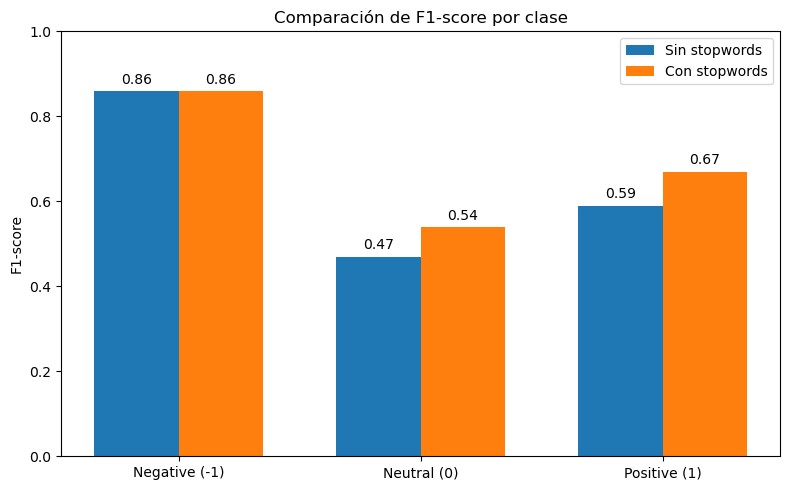

In [ ]:
# Comparación de F1-score por clase
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']
f1_nostop = [0.86, 0.47, 0.59]
f1_stop = [0.86, 0.54, 0.67]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
bars1 = ax.bar(x - width/2, f1_nostop, width, label='Sin stopwords')
bars2 = ax.bar(x + width/2, f1_stop, width, label='Con stopwords')

ax.set_ylabel('F1-score')
ax.set_title('Comparación de F1-score por clase')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()


✅ Conclusiones

🔹 1. La mayoría de los tweets son negativos

Al analizar el dataset, se encontró que la mayoría de los tweets expresan sentimientos negativos, especialmente hacia aerolíneas como United y US Airways.

Esto indica un fuerte sesgo negativo en las redes sociales hacia estas compañías durante el período analizado.

🔹 2. El modelo con Random Forest y CountVectorizer logró buenos resultados

El modelo de Random Forest alcanzó un accuracy del 78% usando unigramas (n_grams=(1,1)), y se mantuvo en 77% al incluir bigramas (n_grams=(1,2)).

La clase negativa fue la mejor clasificada (F1 ~ 0.86), probablemente por tener mayor representación en los datos.

🔹 3. Incluir stopwords mejora el rendimiento

Contrario a lo que se esperaría en muchos problemas de NLP, mantener las stopwords mejoró el F1-score, especialmente para clases neutral y positiva.

Esto tiene sentido en tareas de análisis de sentimiento, donde palabras como “not”, “don’t”, “no” son fundamentales para captar el tono emocional.

🔹 4. El modelo tuvo dificultades con la clase "neutral"

El F1-score para tweets neutrales fue consistentemente el más bajo (~0.47 sin stopwords, ~0.54 con stopwords).

Esto puede deberse a la ambigüedad del lenguaje o a la menor cantidad de ejemplos de esta clase.

🔹 5. Uso de bigramas ofrece ligera mejora en clases minoritarias

Usar n_gram_range=(1,2) permite al modelo capturar expresiones como “not happy”, “very late”, que ayudan especialmente en tweets positivos y neutrales.

Aun así, el beneficio fue marginal con respecto al costo computacional.

# Exercise 1.4

Predict the sentiment using TfidfVectorizer.

use Random Forest classifier

In [23]:
# Usamos esta columna si ya está procesada
X_text = tweets['text_clean_stop']
y = tweets['airline_sentiment'].map({'negative': -1, 'neutral': 0, 'positive': 1})

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# Vectorización
vectorizer = TfidfVectorizer(ngram_range=(1,2))  # puedes probar también (1,1) o (1,3)
X_tfidf = vectorizer.fit_transform(X_text)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# Modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predicción y evaluación
y_pred = clf.predict(X_test)

print("🔍 Classification Report with TF-IDF:")
print(classification_report(y_test, y_pred))

🔍 Classification Report with TF-IDF:
              precision    recall  f1-score   support

          -1       0.76      0.96      0.85      1889
           0       0.70      0.30      0.42       580
           1       0.75      0.44      0.56       459

    accuracy                           0.75      2928
   macro avg       0.74      0.57      0.61      2928
weighted avg       0.74      0.75      0.72      2928



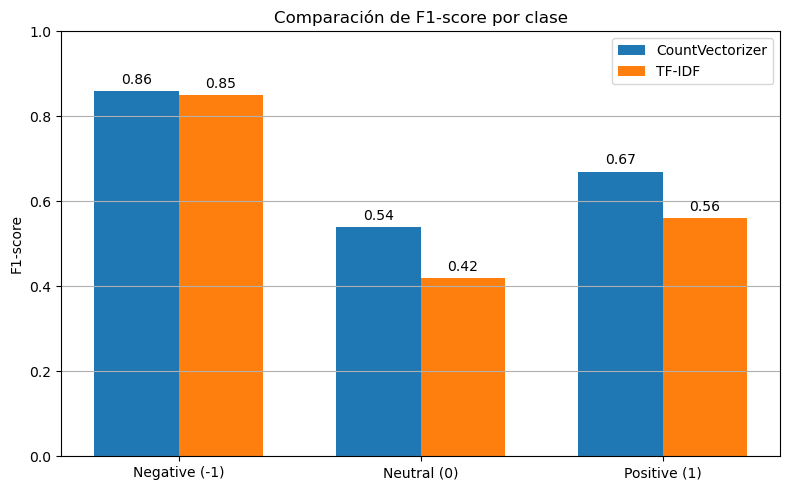

In [ ]:

# F1-scores por clase
labels = ['Negative (-1)', 'Neutral (0)', 'Positive (1)']
f1_count = [0.86, 0.54, 0.67]
f1_tfidf = [0.85, 0.42, 0.56]

x = np.arange(len(labels))
width = 0.35

# Gráfico 1: Comparación Count vs TF-IDF
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, f1_count, width, label='CountVectorizer')
bars2 = ax.bar(x + width/2, f1_tfidf, width, label='TF-IDF')

ax.set_ylabel('F1-score')
ax.set_title('Comparación de F1-score por clase')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.legend()
ax.bar_label(bars1, fmt='%.2f', padding=3)
ax.bar_label(bars2, fmt='%.2f', padding=3)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

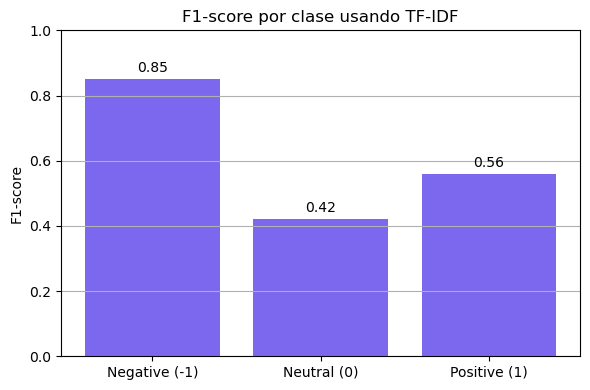

In [26]:
# Gráfico 2: F1-score de TF-IDF solo
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, f1_tfidf, color='mediumslateblue')

ax.set_ylabel('F1-score')
ax.set_title('F1-score por clase usando TF-IDF')
ax.set_ylim(0, 1)
ax.bar_label(bars, fmt='%.2f', padding=3)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

✅ Conclusión sobre el desempeño: CountVectorizer vs TF-IDF

📈 Gráfico comparativo de F1-score por clase:
El gráfico muestra que el modelo usando CountVectorizer (unigramas + bigramas) supera consistentemente al modelo con TF-IDF en las clases neutral y positiva.

En la clase negativa, ambos enfoques obtienen un F1-score muy similar (0.86 vs 0.85), lo que indica que ambos capturan bien esta categoría (la más representada en el dataset).



¿Por qué ocurre esto?

TF-IDF penaliza palabras comunes, lo cual puede ser un problema en análisis de sentimiento, donde incluso las palabras comunes como "not", "good", "late", "very" pueden ser cruciales para el tono del tweet.

CountVectorizer retiene más información bruta de frecuencias, lo que parece beneficiar más a este conjunto de datos en particular.

Aunque TF-IDF es una técnica poderosa, en este caso particular el uso de CountVectorizer con bigramas y stopwords incluidos ofrece mejor rendimiento global y por clase, especialmente en clases minoritarias.
Para este tipo de problema de sentimiento con texto corto y expresivo como los tweets, las palabras comunes tienen valor, y no deberían descartarse o penalizarse.